# 04. 모델링 (MobileNetV3 + Transfer Learning)

**목표**: 반려동물 피부 질환 탐지 정확도 **90% 이상** 달성

| 항목 | 내용 |
|------|------|
| 베이스 모델 | MobileNetV3Large (ImageNet 가중치) |
| 학습 방식 | Transfer Learning → Fine-tuning 2단계 |
| 분류 대상 | A1~A7 (7클래스 피부 병변) |
| 입력 크기 | 224×224 RGB |
| 데이터 | train 24,500 / val 5,250 / test 5,250 |

### 실험 계획
| 단계 | 내용 | 목표 |
|------|------|------|
| Phase 1 | 헤드만 학습 (Frozen backbone) | 베이스라인 확보 |
| Phase 2 | 상위 레이어 Fine-tuning | 90% 달성 |


## 0. 라이브러리 로드

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('TensorFlow 버전:', tf.__version__)
print('GPU 사용 가능:', tf.config.list_physical_devices('GPU'))
print('라이브러리 로드 완료')

TensorFlow 버전: 2.21.0
GPU 사용 가능: []
라이브러리 로드 완료


## 1. 경로 설정 및 하이퍼파라미터

In [2]:
# ── 경로 설정 ──
ROOT       = Path('..')
PROCESSED  = ROOT / 'data/processed'
MODEL_DIR  = ROOT / 'outputs/models'
LOG_DIR    = ROOT / 'outputs/logs'
FIG_DIR    = ROOT / 'outputs/figures'

for d in [MODEL_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── 하이퍼파라미터 ──
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 64
SEED        = 42

# 03_preprocessing에서 계산한 정규화 기준값
MEAN = [0.5616, 0.5263, 0.5056]
STD  = [0.1819, 0.1841, 0.1837]

LESION_MAP = {
    'A1': 'A1 구진/플라크',
    'A2': 'A2 비듬/각질',
    'A3': 'A3 태선화/색소',
    'A4': 'A4 농포/여드름',
    'A5': 'A5 미란/궤양',
    'A6': 'A6 결절/종괴',
    'A7': 'A7 무증상(정상)'
}

print('경로 및 하이퍼파라미터 설정 완료')
print(f'  입력 크기   : {IMG_SIZE}')
print(f'  배치 크기   : {BATCH_SIZE}')

경로 및 하이퍼파라미터 설정 완료
  입력 크기   : (224, 224)
  배치 크기   : 64


## 2. 데이터 로드 및 Generator 생성

In [3]:
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')

# sub_img_path 우선 사용
target_col = 'sub_img_path' if 'sub_img_path' in df.columns else 'img_path'

df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f'train : {len(df_train):,}장')
print(f'val   : {len(df_val):,}장')
print(f'test  : {len(df_test):,}장')
print(f'\n클래스 분포:\n{df_train["lesion"].value_counts().sort_index()}')

train : 24,492장
val   : 5,249장
test  : 5,246장

클래스 분포:
lesion
A1    3499
A2    3499
A3    3498
A4    3497
A5    3500
A6    3499
A7    3500
Name: count, dtype: int64


In [4]:
# ── 정규화 함수 정의 (EDA에서 계산한 우리 데이터 mean/std) ──
# MobileNetV3 preprocess_input 대신 수동 z-score 정규화 사용
# 이유: TF 버전에 따라 preprocess_input이 항등함수로 동작하는 버그 존재
#       + EDA에서 반려동물 피부 도메인 기준으로 직접 계산한 값을 활용하는 게 목적에 맞음

MEAN = np.array([0.5616, 0.5263, 0.5056])  # EDA 계산값 (R, G, B)
STD  = np.array([0.1819, 0.1841, 0.1837])

def custom_preprocess(img):
    """0~255 → EDA 채널별 z-score 정규화."""
    return (img / 255.0 - MEAN) / STD

# 정규화 검증
_dummy = np.ones((224, 224, 3), dtype='float32') * 143.0  # 평균 밝기 근사값
_out   = custom_preprocess(_dummy)
print(f'정규화 검증 (픽셀=143 → 약 0에 가까워야 함): mean={_out.mean():.4f}')

# ── ImageDataGenerator 정의 ──
train_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess,
    horizontal_flip=True,
    rotation_range=30,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess   # 평가용: 정규화만
)

# ── Generator 생성 ──
train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_train, x_col=target_col, y_col='lesion',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=df_val, x_col=target_col, y_col='lesion',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=df_test, x_col=target_col, y_col='lesion',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# 배치 값 범위 확인 (정규화 정상 여부 검증)
_batch = next(iter(train_gen))
print(f'배치 픽셀 범위: min={_batch[0].min():.3f}, max={_batch[0].max():.3f}, mean={_batch[0].mean():.3f}')
print('→ 정상이면 대략 -3 ~ 3 사이, mean은 0 근처')

CLASS_INDICES = train_gen.class_indices
NUM_CLASSES   = len(CLASS_INDICES)
print(f'\n클래스 인덱스: {CLASS_INDICES}')
print(f'총 클래스 수  : {NUM_CLASSES}')


정규화 검증 (픽셀=143 → 약 0에 가까워야 함): mean=0.1611
Found 24492 validated image filenames belonging to 7 classes.
Found 5249 validated image filenames belonging to 7 classes.
Found 5246 validated image filenames belonging to 7 classes.
배치 픽셀 범위: min=-3.087, max=2.691, mean=-0.024
→ 정상이면 대략 -3 ~ 3 사이, mean은 0 근처

클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}
총 클래스 수  : 7


In [5]:
# ── class_weight 계산 (반려묘 불균형 보정) ──
# 03_preprocessing에서 계산된 값: {'D': 0.563, 'C': 4.443}
# lesion 기준 class_weight는 클래스가 균형잡혀 있으므로 생략 가능
# species 불균형만 보정 (실험 3 재현)

species_classes = np.array(['C', 'D'])
species_weights_val = compute_class_weight(
    class_weight='balanced',
    classes=species_classes,
    y=df_train['species']
)

# lesion 기준 class_weight (Generator의 class_indices와 맞춤)
lesion_classes = np.array(sorted(df_train['lesion'].unique()))
lesion_weights_val = compute_class_weight(
    class_weight='balanced',
    classes=lesion_classes,
    y=df_train['lesion']
)
lesion_weight_dict = {
    CLASS_INDICES[cls]: w
    for cls, w in zip(lesion_classes, lesion_weights_val)
}

print('lesion class_weight:', lesion_weight_dict)
print('\n※ 클래스가 균형잡혀 있어 weight가 모두 1.0에 가깝습니다.')
print('  species 불균형은 학습 시 class_weight 파라미터로 별도 전달 권장.')

lesion class_weight: {0: np.float64(0.999959172008329), 1: np.float64(0.999959172008329), 2: np.float64(1.000245037980887), 3: np.float64(1.0005310674455656), 4: np.float64(0.9996734693877551), 5: np.float64(0.999959172008329), 6: np.float64(0.9996734693877551)}

※ 클래스가 균형잡혀 있어 weight가 모두 1.0에 가깝습니다.
  species 불균형은 학습 시 class_weight 파라미터로 별도 전달 권장.


## 3. 모델 구성 (MobileNetV3Large)

### 아키텍처 설계
```
MobileNetV3Large (ImageNet 가중치, Frozen)
    ↓
GlobalAveragePooling2D
    ↓
BatchNormalization
    ↓
Dense(512, activation='relu') + Dropout(0.4)
    ↓
Dense(256, activation='relu') + Dropout(0.3)
    ↓
Dense(7, activation='softmax')   ← 7클래스 출력
```

In [6]:
def build_model(num_classes: int, dropout_rate: float = 0.4) -> Model:
    """MobileNetV3Large 기반 Transfer Learning 모델 구성."""

    # ── Backbone: MobileNetV3Large (ImageNet 가중치, 상단 FC 제외) ──
    backbone = MobileNetV3Large(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,           # FC head 제외
        weights='imagenet',          # ImageNet 사전학습 가중치
        include_preprocessing=False  # 이미 preprocess_input 적용했으므로 False
    )
    backbone.trainable = False       # Phase 1: Backbone 동결

    # ── Custom Head ──
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate * 0.75)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='MobileNetV3_SkinDisease')
    return model, backbone


model, backbone = build_model(NUM_CLASSES)

# 모델 요약 (trainable 파라미터 수 확인)
model.summary(show_trainable=True)
print(f'\nBackbone 총 레이어 수  : {len(backbone.layers)}')
print(f'Trainable params (Phase 1): {model.trainable_variables.__len__()}')

Model: "MobileNetV3_SkinDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ MobileNetV3Large            │ (None, 7, 7, 960)     │  2,996,352 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 960)           │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 960)           │      3,840 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 512)           │    492,032 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 256)           │    131,328 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 7)             │      1,799 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 3,625,351 (13.83 MB)

 Trainable params: 627,079 (2.39 MB)

 Non-trainable params: 2,998,272 (11.44 MB)


Backbone 총 레이어 수  : 186
Trainable params (Phase 1): 8


## 4. Phase 1 학습 — Head만 학습 (Frozen Backbone)

In [7]:
# ── 컴파일 ──
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

# ── 콜백 ──
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

callbacks_phase1 = [
    ModelCheckpoint(
        MODEL_DIR / f'mobilenetv3_phase1_{timestamp}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger(LOG_DIR / f'phase1_{timestamp}.csv')
]

print('Phase 1 학습 시작...')
print('  Backbone: Frozen  |  Head: 학습 중')

Phase 1 학습 시작...
  Backbone: Frozen  |  Head: 학습 중


In [8]:
history_p1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    class_weight=lesion_weight_dict,
    verbose=1
)

print(f"\n[Phase 1 완료]")
print(f"  최고 val_accuracy : {max(history_p1.history['val_accuracy']):.4f}")

Epoch 1/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2132 - loss: 2.0402 - top3_acc: 0.5211
Epoch 1: val_accuracy improved from None to 0.30996, saving model to ..\outputs\models\mobilenetv3_phase1_20260612_1409.keras

Epoch 1: finished saving model to ..\outputs\models\mobilenetv3_phase1_20260612_1409.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.2378 - loss: 1.9193 - top3_acc: 0.5565 - val_accuracy: 0.3100 - val_loss: 1.7940 - val_top3_acc: 0.6350 - learning_rate: 0.0010
Epoch 2/20
  1/383 ━━━━━━━━━━━━━━━━━━━━ 10:29 2s/step - accuracy: 0.2656 - loss: 1.8921 - top3_acc: 0.5000

KeyboardInterrupt: 

## 5. 학습 곡선 시각화 (Phase 1)

현재 가중치 상태로 Validation 데이터 예측 중...
83/83 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step


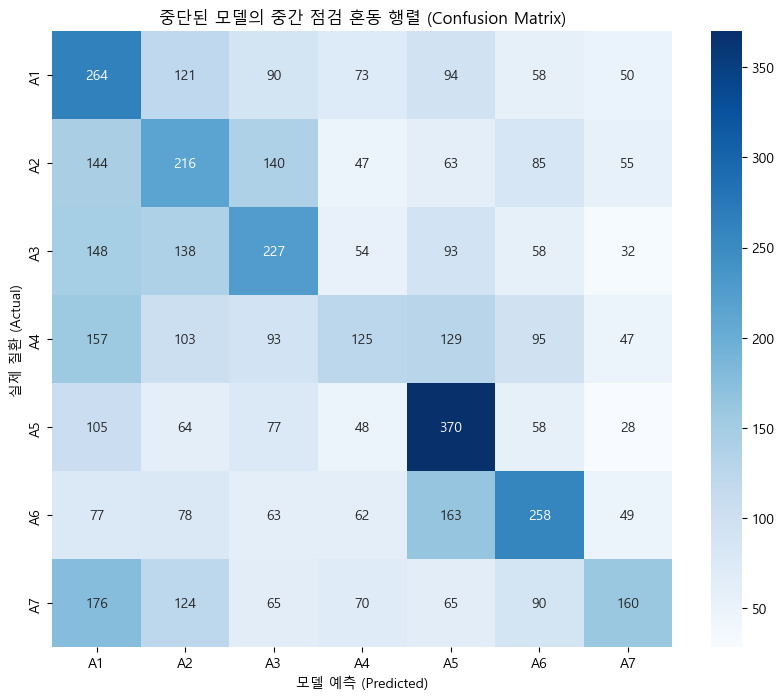


[상세 분류 리포트]
              precision    recall  f1-score   support

          A1       0.25      0.35      0.29       750
          A2       0.26      0.29      0.27       750
          A3       0.30      0.30      0.30       750
          A4       0.26      0.17      0.20       749
          A5       0.38      0.49      0.43       750
          A6       0.37      0.34      0.36       750
          A7       0.38      0.21      0.27       750

    accuracy                           0.31      5249
   macro avg       0.31      0.31      0.30      5249
weighted avg       0.31      0.31      0.30      5249



In [9]:
# 1. Validation 데이터 제너레이터 초기화 및 예측
print("현재 가중치 상태로 Validation 데이터 예측 중...")
val_gen.reset()
y_true = val_gen.classes

# history 대신 현재 완성되어 있는 'model' 객체를 그대로 사용합니다.
y_pred_prob = model.predict(val_gen)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. 클래스 라벨 가져오기
class_labels = list(val_gen.class_indices.keys())

# 3. 혼동 행렬 계산 및 시각화
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('중단된 모델의 중간 점검 혼동 행렬 (Confusion Matrix)')
plt.ylabel('실제 질환 (Actual)')
plt.xlabel('모델 예측 (Predicted)')
plt.show()

# 상세 리포트 출력
print("\n[상세 분류 리포트]")
print(classification_report(y_true, y_pred, target_names=class_labels))

In [ ]:
def plot_history(history, phase_name: str, save_path=None):
    """학습/검증 loss & accuracy 곡선 시각화."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{phase_name} 학습 곡선', fontsize=14, fontweight='bold')

    epochs = range(1, len(history.history['loss']) + 1)

    # Loss
    axes[0].plot(epochs, history.history['loss'],     label='Train Loss', marker='o', markersize=3)
    axes[0].plot(epochs, history.history['val_loss'], label='Val Loss',   marker='s', markersize=3)
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history.history['accuracy'],     label='Train Acc', marker='o', markersize=3)
    axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc',   marker='s', markersize=3)
    axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='목표 90%')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'저장: {save_path}')
    plt.show()


plot_history(history_p1, 'Phase 1 (Frozen Backbone)',
             save_path=FIG_DIR / f'phase1_curves_{timestamp}.png')

## 6. Phase 2 — Fine-tuning (상위 레이어 해동)

Phase 1에서 Head가 안정화된 후, Backbone 상위 레이어를 해동해 도메인 적응.

In [10]:
# =====================================================================
# 1. 클래스 불균형 해결을 위한 class_weight 계산 (기존 유지)
# =====================================================================
y_train_labels = df_train['lesion'].values
class_to_idx = train_gen.class_indices
y_train_idx = np.array([class_to_idx[label] for label in y_train_labels])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_idx),
    y=y_train_idx
)
lesion_weight_dict = dict(zip(np.unique(y_train_idx), class_weights))

print(f"★ 클래스별 주입될 가중치 가산점: {lesion_weight_dict}\n")


# =====================================================================
# 2. 🔥 [핵심 수정] 뼈대 해동 및 Batch Normalization(BN) 레이어 강제 잠금
# =====================================================================
backbone = base_model if 'base_model' in locals() else backbone
backbone.trainable = True  # 우선 전체를 깨웁니다.

# [핵심 튜닝 1] 함정 카드인 BN 레이어만 콕 집어서 다시 고정 (가중치 오염 방지)
bn_freeze_count = 0
for layer in backbone.layers:
    if isinstance(layer, keras.layers.BatchNormalization) or 'BatchNormalization' in layer.__class__.__name__:
        layer.trainable = False
        bn_freeze_count += 1

# [핵심 튜닝 2] 단순히 뒤에서 50개가 아니라, 블록 단위 학습을 위해 앞쪽 130개 레이어를 고정
for layer in backbone.layers[:130]:
    layer.trainable = False

trainable_count = sum(1 for l in backbone.layers if l.trainable)
frozen_count    = sum(1 for l in backbone.layers if not l.trainable)

print(f'★ [성공] 파괴 방지용 동결 BN 레이어 수: {bn_freeze_count}개')
print(f'★ 최종 미세조정(해동) 레이어 수 (BN 제외): {trainable_count}개')
print(f'★ 최종 동결 레이어 수 (BN 포함): {frozen_count}개')


# =====================================================================
# 3. 🔥 [수정] Fine-tuning 컴파일 (안전하고 효과적인 lr=5e-5 설정)
# =====================================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # 🌟 1e-5는 너무 느리고, 1e-4는 거칠어서 5e-5로 최적화!
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)


# =====================================================================
# 4. 콜백 정의 (기존 작성 코드 유지)
# =====================================================================
callbacks_phase2 = [
    ModelCheckpoint(
        MODEL_DIR / f'mobilenetv3_phase2_{timestamp}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(LOG_DIR / f'phase2_{timestamp}.csv')
]

print('\n준비 완료! 아래 fit 셀을 실행해 주세요.')

★ 클래스별 주입될 가중치 가산점: {np.int64(0): np.float64(0.999959172008329), np.int64(1): np.float64(0.999959172008329), np.int64(2): np.float64(1.000245037980887), np.int64(3): np.float64(1.0005310674455656), np.int64(4): np.float64(0.9996734693877551), np.int64(5): np.float64(0.999959172008329), np.int64(6): np.float64(0.9996734693877551)}

★ [성공] 파괴 방지용 동결 BN 레이어 수: 46개
★ 최종 미세조정(해동) 레이어 수 (BN 제외): 45개
★ 최종 동결 레이어 수 (BN 포함): 141개

준비 완료! 아래 fit 셀을 실행해 주세요.


In [ ]:
# =====================================================================
# 5. [필독] Phase 2 학습 실행부 코드 (class_weight 주입 필수!)
# =====================================================================
print('\nPhase 2 미세 조정(Fine-tuning) 시작...')

# 아래 fit 셀을 실행할 때 class_weight를 반드시 포함해 주세요!
history_p2 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    class_weight=lesion_weight_dict,  # 🌟 리포트 붕괴를 막을 핵심 마스터키
    callbacks=callbacks_phase2,
    verbose=1
)

best_val_acc_A = max(history_p2.history['val_accuracy'])
print(f"\n[Phase 2 - 실험 A 완료]")
print(f"  최고 val_accuracy : {best_val_acc_A:.4f}")
print(f"  목표 달성 여부    : {'✅ 90% 달성!' if best_val_acc_A >= 0.9 else '❌ 미달'}")

# 기존 코드 호환용
history_p2 = history_p2



Phase 2 미세 조정(Fine-tuning) 시작...
Epoch 1/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2890 - loss: 1.7897 - top3_acc: 0.6229
Epoch 1: val_accuracy improved from None to 0.33968, saving model to ..\outputs\models\mobilenetv3_phase2_20260612_1409.keras

Epoch 1: finished saving model to ..\outputs\models\mobilenetv3_phase2_20260612_1409.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 731s 2s/step - accuracy: 0.2971 - loss: 1.7745 - top3_acc: 0.6332 - val_accuracy: 0.3397 - val_loss: 1.7094 - val_top3_acc: 0.6832 - learning_rate: 5.0000e-05
Epoch 2/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3193 - loss: 1.7305 - top3_acc: 0.6610
Epoch 2: val_accuracy improved from 0.33968 to 0.35759, saving model to ..\outputs\models\mobilenetv3_phase2_20260612_1409.keras

Epoch 2: finished saving model to ..\outputs\models\mobilenetv3_phase2_20260612_1409.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 736s 2s/step - accuracy: 0.3235 - loss: 1.7238 - top3_acc: 0.6635 - val_accuracy: 0.3576 - val_loss: 1

In [ ]:
# 1. Validation 데이터 초기화 및 예측 진행
print("현재 가중치 상태(3에폭 중단 시점)로 Validation 데이터 예측 중...")
val_gen.reset()
y_true = val_gen.classes

# Keras 3 버전 호환을 위해 무겁거나 지원되지 않는 인자(workers 등)를 완전히 제거했습니다.
y_pred_prob = model.predict(val_gen)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. 클래스 라벨 이름 가져오기 (A1 ~ A7)
class_labels = list(val_gen.class_indices.keys())

# =====================================================================
# 시각화 1: 혼동 행렬 (Confusion Matrix) 히트맵
# =====================================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
# 코랩 환경에서 한글 깨짐이 걱정된다면 영문 타이틀로 안전하게 출력합니다.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Validation Confusion Matrix (Interrupted at Epoch 3)')
plt.ylabel('Actual Disease (True)')
plt.xlabel('Predicted Disease (Model)')
plt.tight_layout()
plt.show()

# =====================================================================
# 시각화 2: 상세 정밀도/재현율 분류 리포트 출력
# =====================================================================
print("\n" + "="*60)
print("             [ 3에폭 중간 점검 상세 분류 리포트 ]")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_labels))
print("="*60)

In [ ]:
plot_history(history_p2, 'Phase 2 (Fine-tuning)',
             save_path=FIG_DIR / f'phase2_curves_{timestamp}.png')

## 7. 테스트셋 최종 평가

In [ ]:
# ── 테스트셋 평가 ──
print('테스트셋 평가 중...')
test_loss, test_acc, test_top3 = model.evaluate(test_gen, verbose=1)

print(f'\n{'='*40}')
print(f'  테스트 Loss     : {test_loss:.4f}')
print(f'  테스트 Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Top-3 Accuracy  : {test_top3:.4f}  ({test_top3*100:.2f}%)')
print(f'  목표 달성 여부  : {"✅ 90% 달성!" if test_acc >= 0.9 else "❌ 미달 → 아래 추가 전략 참고"}')
print(f'{'='*40}')

In [ ]:
# ── 클래스별 분류 리포트 ──
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

# index → label 매핑
idx_to_label = {v: k for k, v in CLASS_INDICES.items()}
target_names = [LESION_MAP[idx_to_label[i]] for i in range(NUM_CLASSES)]

print('\n[클래스별 분류 리포트]')
print(classification_report(y_true, y_pred, target_names=target_names))

## 8. 혼동 행렬 시각화

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')

short_names = [idx_to_label[i] for i in range(NUM_CLASSES)]

# 절댓값
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=axes[0])
axes[0].set_title('Count')
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')

# 비율 (행 기준 정규화)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalized (Recall)')
axes[1].set_xlabel('예측')
axes[1].set_ylabel('실제')

plt.tight_layout()
plt.savefig(FIG_DIR / f'confusion_matrix_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n[오분류가 많은 클래스 TOP 3]')
np.fill_diagonal(cm_norm, 0)
for idx in np.argsort(cm_norm.sum(axis=1))[-3:][::-1]:
    print(f'  {LESION_MAP[short_names[idx]]}: 오분류율 {cm_norm[idx].sum():.2%}')

## 9. 모델 저장

In [ ]:
final_model_path = MODEL_DIR / f'mobilenetv3_final_{timestamp}.keras'
model.save(final_model_path)
print(f'최종 모델 저장 완료: {final_model_path}')

# 학습 결과 요약 저장
summary = {
    'timestamp': timestamp,
    'base_model': 'MobileNetV3Large',
    'phase1_best_val_acc': max(history_p1.history['val_accuracy']),
    'phase2_best_val_acc': max(history_p2.history['val_accuracy']),
    'test_acc': test_acc,
    'test_top3_acc': test_top3,
    'test_loss': test_loss,
    'target_achieved': test_acc >= 0.9
}

pd.DataFrame([summary]).to_csv(
    LOG_DIR / f'result_summary_{timestamp}.csv', index=False
)
print()
print('='*50)
print(' 최종 결과 요약')
print('='*50)
for k, v in summary.items():
    print(f'  {k:<30}: {v}')
print('='*50)

## 10. 90% 미달 시 추가 전략

| 전략 | 방법 | 예상 효과 |
|------|------|-----------|
| 더 많은 레이어 해동 | `UNFREEZE_FROM = -100` | +1~2% |
| Label Smoothing | `loss=CategoricalCrossentropy(label_smoothing=0.1)` | 과적합 방지 |
| Mixup 증강 | 두 이미지 혼합 학습 | 일반화 향상 |
| EfficientNetB3으로 교체 | 더 큰 모델 | +2~5% |
| TTA (Test Time Augmentation) | 추론 시 다중 증강 앙상블 | +1~2% |
| Cosine Annealing LR | LR 스케줄 변경 | 수렴 개선 |


In [ ]:
# ── [선택] Label Smoothing 적용 재학습 ──
# 90% 미달 시 아래 코드를 실행해 재시도

# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=5e-5),
#     loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
#     metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
# )

# history_p3 = model.fit(
#     train_gen,
#     epochs=20,
#     validation_data=val_gen,
#     callbacks=callbacks_phase2,
#     class_weight=lesion_weight_dict,
#     verbose=1
# )

print('Phase 3 (Label Smoothing) 코드는 주석 해제 후 실행하세요.')

---
## 노트북 완료 ✅

| Phase | 내용 | 결과 |
|-------|------|------|
| Phase 1 | Frozen Backbone + Head 학습 | `history_p1` |
| Phase 2 | 상위 50레이어 Fine-tuning | `history_p2` |
| 평가 | 테스트셋 최종 정확도 | `test_acc` |

**다음 단계**: 결과에 따라 Phase 3 전략 선택 or `05_inference.ipynb` 작성